In [45]:
pip install whitebox geopandas shapely

    kubernetes (>=9.0.0a1.0) ; extra == 'all_extras'
               ~~~~~~~~~~^
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import whitebox
import geopandas as gpd
from shapely.geometry import Point

wbt = whitebox.WhiteboxTools()
wbt.set_verbose_mode(False)

dem_input = "dawasamu_dem_input.tif"
filled_dem = "dem_filled.tif"
flow_dir = "flow_direction.tif"
flow_accum = "flow_accumulation.tif"
outlet_vector = "outlet_point.shp"
catchment_raster = "catchment.tif"
catchment_vector = "catchment_aoi.shp"

# 1. Fill hydrological depressions/sinks
wbt.fill_depressions(dem_input, filled_dem)

# 2. Compute D8 Flow Pointer (Direction)
wbt.d8_pointer(filled_dem, flow_dir)

# 3. Compute D8 Flow Accumulation
wbt.d8_flow_accumulation(filled_dem, flow_accum)

# 4. Save outlet point (Replace X and Y with your stream pour point in EPSG:32760 meters)
outlet_x = 659713.0  # Replace with target Easting (m)
outlet_y = 8051296.8 # Replace with target Northing (m)

outlet_gdf = gpd.GeoDataFrame(geometry=[Point(outlet_x, outlet_y)], crs="EPSG:32760")
outlet_gdf.to_file(outlet_vector)

# 5. Delineate watershed from outlet point
wbt.watershed(flow_dir, outlet_vector, catchment_raster)

# 6. Convert delineated raster watershed to vector shapefile for InVEST AOI
wbt.raster_to_vector_polygons(catchment_raster, catchment_vector)

print(f"Catchment AOI shapefile successfully created: {catchment_vector}")

In [ ]:
outlet_gdf.explore()

In [56]:
import os
import whitebox
import geopandas as gpd
import rasterio
import numpy as np
from shapely.geometry import Point

# 1. Setup paths
work_dir = os.path.abspath("/home/jovyan/invest/dawasamu/data")

dem_input = os.path.join(work_dir, "1-dawasamu-dem.tif")
filled_dem = os.path.join(work_dir, "dem_filled.tif")
flow_dir = os.path.join(work_dir, "flow_direction.tif")
flow_accum = os.path.join(work_dir, "flow_accumulation.tif")
streams_raster = os.path.join(work_dir, "streams.tif")
outlet_raw = os.path.join(work_dir, "outlet_raw.shp")
outlet_snapped = os.path.join(work_dir, "outlet_snapped.shp")
catchment_raster = os.path.join(work_dir, "catchment.tif")
catchment_vector = os.path.join(work_dir, "catchment_aoi.shp")

wbt = whitebox.WhiteboxTools()
wbt.set_working_dir(work_dir)
wbt.set_verbose_mode(False)

# 2. Re-run flow routing steps
print("1. Running hydrological flow routing...")
wbt.fill_depressions(dem_input, filled_dem)
wbt.d8_pointer(filled_dem, flow_dir)
wbt.d8_flow_accumulation(filled_dem, flow_accum)
wbt.extract_streams(flow_accum, streams_raster, threshold=500.0)

# 3. Automatically find the major stream pour point inside the DEM bounds
with rasterio.open(flow_accum) as src:
    accum_data = src.read(1)
    nodata = src.nodata
    
    # Mask out NoData
    if nodata is not None:
        accum_data[accum_data == nodata] = 0
    accum_data[np.isnan(accum_data)] = 0
    
    # Get index of pixel with highest accumulation (river mouth/outlet)
    max_idx = np.unravel_index(np.argmax(accum_data), accum_data.shape)
    
    # Convert pixel (row, col) to map coordinates (X, Y) in EPSG:32760
    outlet_x, outlet_y = src.transform * (max_idx[1], max_idx[0])

print(f"2. Auto-detected stream outlet point: X={outlet_x:.2f}, Y={outlet_y:.2f}")

# 4. Save outlet shapefile
outlet_gdf = gpd.GeoDataFrame(geometry=[Point(outlet_x, outlet_y)], crs="EPSG:32760")
outlet_gdf.to_file(outlet_raw)

# 5. Snap outlet point to stream network
print("3. Snapping pour point...")
wbt.jenson_snap_pour_points(
    pour_pts=outlet_raw,
    streams=streams_raster,
    output=outlet_snapped,
    snap_dist=500.0
)

# 6. Delineate watershed
print("4. Delineating watershed...")
wbt.watershed(
    d8_pntr=flow_dir,
    pour_pts=outlet_snapped,
    output=catchment_raster
)

# 7. Check catchment raster contents
with rasterio.open(catchment_raster) as src:
    data = src.read(1)
    nodata = src.nodata
    valid_cells = np.sum((data != nodata) & (data > 0)) if nodata is not None else np.sum(data > 0)
    print(f"Catchment Raster Check: Found {valid_cells} valid catchment cells.")

# 8. Convert to polygon shapefile
print("5. Converting raster to polygon shapefile...")
wbt.raster_to_vector_polygons(
    i=catchment_raster,
    output=catchment_vector
)

if os.path.exists(catchment_vector):
    print(f"\nSUCCESS: Catchment AOI shapefile successfully created at: {catchment_vector}")

1. Running hydrological flow routing...
2. Auto-detected stream outlet point: X=664635.00, Y=8034795.00
3. Snapping pour point...
4. Delineating watershed...
Catchment Raster Check: Found 1197340 valid catchment cells.
5. Converting raster to polygon shapefile...

SUCCESS: Catchment AOI shapefile successfully created at: /home/jovyan/invest/dawasamu/data/catchment_aoi.shp


1. Calculating hydrological flow routing on inland elevation...
2. Selected inland river pour point: X=647835.00, Y=8034795.00
3. Plotting delineated catchment...


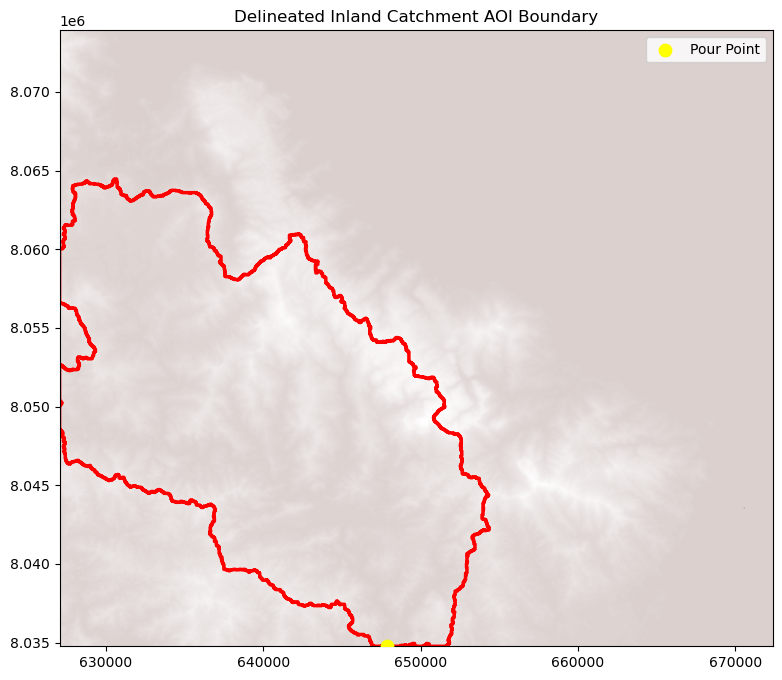

In [57]:
import os
import whitebox
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point

work_dir = os.path.abspath("/home/jovyan/invest/dawasamu/data")

dem_input = os.path.join(work_dir, "1-dawasamu-dem.tif")
filled_dem = os.path.join(work_dir, "dem_filled.tif")
flow_dir = os.path.join(work_dir, "flow_direction.tif")
flow_accum = os.path.join(work_dir, "flow_accumulation.tif")
streams_raster = os.path.join(work_dir, "streams.tif")
outlet_raw = os.path.join(work_dir, "outlet_raw.shp")
outlet_snapped = os.path.join(work_dir, "outlet_snapped.shp")
catchment_raster = os.path.join(work_dir, "catchment.tif")
catchment_vector = os.path.join(work_dir, "catchment_aoi.shp")

wbt = whitebox.WhiteboxTools()
wbt.set_working_dir(work_dir)
wbt.set_verbose_mode(False)

# 1. Mask out ocean/coastal flat area (elevation <= 2m) to isolate inland river networks
with rasterio.open(dem_input) as src:
    dem_data = src.read(1)
    meta = src.meta.copy()
    
    # Mask out flat sea level/ocean cells for stream accumulation calculation
    dem_masked = np.where(dem_data <= 2, np.nan, dem_data)

dem_masked_path = os.path.join(work_dir, "dem_inland.tif")
with rasterio.open(dem_masked_path, 'w', **meta) as dst:
    dst.write(dem_masked, 1)

# 2. Run hydrological flow routing on inland terrain
print("1. Calculating hydrological flow routing on inland elevation...")
wbt.fill_depressions(dem_masked_path, filled_dem)
wbt.d8_pointer(filled_dem, flow_dir)
wbt.d8_flow_accumulation(filled_dem, flow_accum)
wbt.extract_streams(flow_accum, streams_raster, threshold=200.0)

# 3. Locate the largest inland stream outlet near the coast
with rasterio.open(flow_accum) as accum_src, rasterio.open(dem_input) as dem_src:
    accum = accum_src.read(1)
    elev = dem_src.read(1)
    
    # Only consider stream cells above sea level (elevation > 5m)
    inland_stream_mask = (elev > 5) & (accum > 200)
    accum_inland = np.where(inland_stream_mask, accum, 0)
    
    # Pick the highest accumulation point on inland terrain
    max_idx = np.unravel_index(np.argmax(accum_inland), accum_inland.shape)
    outlet_x, outlet_y = accum_src.transform * (max_idx[1], max_idx[0])

print(f"2. Selected inland river pour point: X={outlet_x:.2f}, Y={outlet_y:.2f}")

# 4. Save and Snap Pour Point
outlet_gdf = gpd.GeoDataFrame(geometry=[Point(outlet_x, outlet_y)], crs="EPSG:32760")
outlet_gdf.to_file(outlet_raw)

wbt.jenson_snap_pour_points(
    pour_pts=outlet_raw,
    streams=streams_raster,
    output=outlet_snapped,
    snap_dist=300.0
)

# 5. Delineate Catchment
wbt.watershed(
    d8_pntr=flow_dir,
    pour_pts=outlet_snapped,
    output=catchment_raster
)

# 6. Vectorize Catchment
wbt.raster_to_vector_polygons(
    i=catchment_raster,
    output=catchment_vector
)

print("3. Plotting delineated catchment...")
catchment = gpd.read_file(catchment_vector)

with rasterio.open(dem_input) as src:
    fig, ax = plt.subplots(figsize=(10, 8))
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    ax.imshow(src.read(1), cmap="terrain", extent=extent)
    catchment.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2.5)
    plt.scatter([outlet_x], [outlet_y], color="yellow", s=80, zorder=5, label="Pour Point")
    plt.legend()
    plt.title("Delineated Inland Catchment AOI Boundary")
    plt.show()

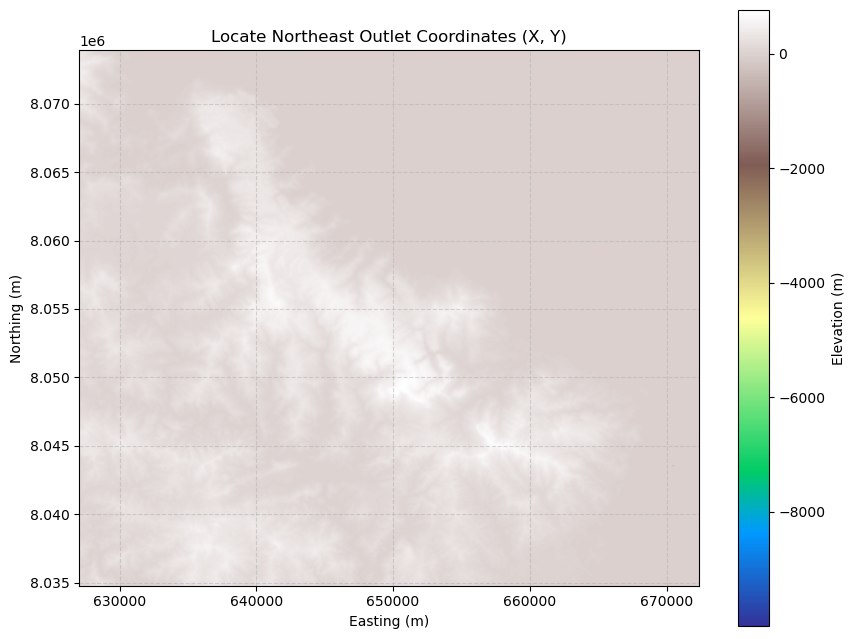

In [58]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("1-dawasamu-dem.tif") as src:
    dem_data = src.read(1)
    bounds = src.bounds

plt.figure(figsize=(10, 8))
plt.imshow(dem_data, cmap="terrain", extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
plt.colorbar(label="Elevation (m)")
plt.title("Locate Northeast Outlet Coordinates (X, Y)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [59]:
-17.621548,178.499603

(-17.621548, 178.499603)

In [60]:
# # Pass your custom coordinates into the pour point shapefile
# target_x = 659040.6  # Update with your desired Easting
# target_y = 8051086.0  # Update with your desired Northing

target_x = 659713.0  # Replace with target Easting (m)
target_y = 8051296.8 # Replace with target Northing (m)

outlet_gdf = gpd.GeoDataFrame(geometry=[Point(target_x, target_y)], crs="EPSG:32760")
outlet_gdf.to_file(outlet_raw)

# Snap and run watershed
wbt.jenson_snap_pour_points(
    pour_pts=outlet_raw,
    streams=streams_raster,
    output=outlet_snapped,
    snap_dist=300.0
)

wbt.watershed(
    d8_pntr=flow_dir,
    pour_pts=outlet_snapped,
    output=catchment_raster
)

wbt.raster_to_vector_polygons(i=catchment_raster, output="catchment_northeast.shp")

0

In [61]:
# # Delineate all major basins across the DEM automatically
# wbt.basins(
#     d8_pntr=flow_dir,
#     output="all_basins.tif"
# )

# # Vectorize all basins into a single multi-polygon shapefile
# wbt.raster_to_vector_polygons(
#     i="all_basins.tif",
#     output="all_catchments.shp"
# )

In [62]:
import os
import whitebox

work_dir = os.path.abspath("/home/jovyan/invest/dawasamu/data")

wbt = whitebox.WhiteboxTools()
wbt.set_working_dir(work_dir)

# Convert all basins raster to a polygon shapefile
wbt.raster_to_vector_polygons(
    i="all_basins.tif",
    output="all_basins.gpkg"
)

print("Saved polygonized basins to all_basins.gpkg")

./whitebox_tools --run="RasterToVectorPolygons" --wd="/home/jovyan/invest/dawasamu/data" --input='all_basins.tif' --output='all_basins.gpkg' -v --compress_rasters=False

*************************************
* Welcome to RasterToVectorPolygons *
* Powered by WhiteboxTools          *
* www.whiteboxgeo.com               *
*************************************
Reading data...
Clumping polygons: 0%
Clumping polygons: 1%
Clumping polygons: 2%
Clumping polygons: 3%
Clumping polygons: 4%
Clumping polygons: 5%
Clumping polygons: 6%
Clumping polygons: 7%
Clumping polygons: 8%
Clumping polygons: 9%
Clumping polygons: 10%
Clumping polygons: 11%
Clumping polygons: 12%
Clumping polygons: 13%
Clumping polygons: 14%
Clumping polygons: 15%
Clumping polygons: 16%
Clumping polygons: 17%
Clumping polygons: 18%
Clumping polygons: 19%
Clumping polygons: 20%
Clumping polygons: 21%
Clumping polygons: 22%
Clumping polygons: 23%
Clumping polygons: 24%
Clumping polygons: 25%
Clumping polygons: 26%
Clumping poly

In [55]:
Need to polygonise 

SyntaxError: invalid syntax (2881844063.py, line 1)